In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


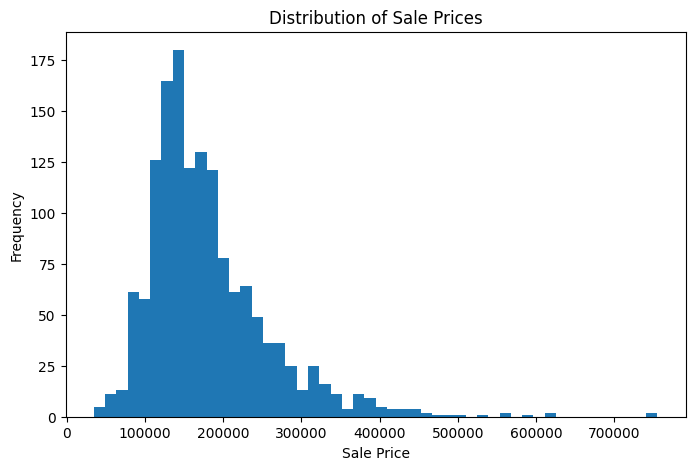

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=50)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices')
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(correlations.head(15))


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


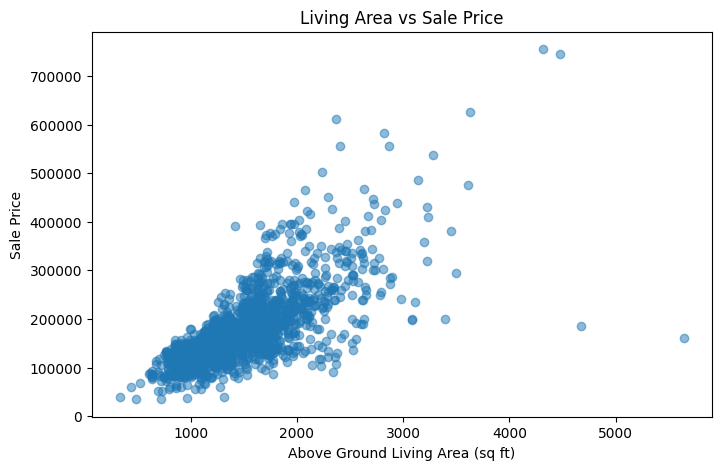

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.title('Living Area vs Sale Price')
plt.show()

In [ ]:
df['OverallQual'].describe()
df['OverallQual'].value_counts().sort_index()

,count
OverallQual,
1,2
2,3
3,20
4,116
5,397
6,374
7,319
8,168
9,43


In [ ]:


x = df['GrLivArea'].values
y = df['SalePrice'].values


X_poly = np.column_stack([x, x**2, x**3])
print(X_poly.shape)
def zscore_normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_poly_scaled, mu, sigma = zscore_normalize(X_poly)

print("Before scaling - mean:", X_poly.mean(axis=0))
print("Before scaling - std:", X_poly.std(axis=0))
print("After scaling - mean:", X_poly_scaled.mean(axis=0))
print("After scaling - std:", X_poly_scaled.std(axis=0))

(1460, 3)
Before scaling - mean: [1.51546370e+03 2.57257073e+06 4.93287479e+09]
Before scaling - std: [5.25300394e+02 2.06346581e+06 7.98312557e+09]
After scaling - mean: [-1.56115608e-16  7.78676971e-17  4.57016464e-17]
After scaling - std: [1. 1. 1.]


X_multi shape: (1460, 8)


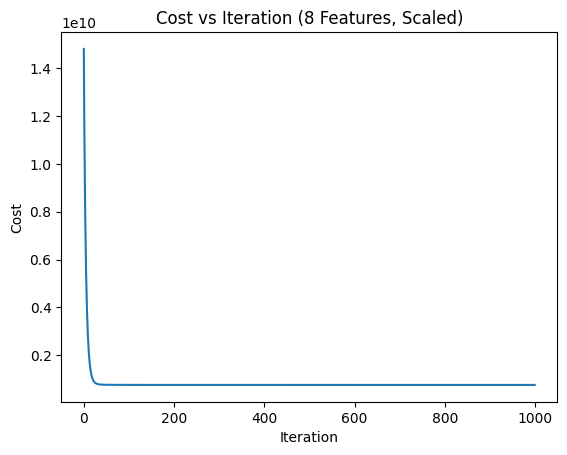


Feature weights:
OverallQual: 32873.86
GrLivArea: 23472.55
GarageCars: 10729.22
GarageArea: 3364.65
TotalBsmtSF: 10634.57
1stFlrSF: 4311.73
FullBath: 911.69
TotRmsAbvGrd: -1374.74

Bias (b): 180921.20

R² score: 0.7621


In [49]:

features_multi = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                   'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd']

X_multi = df[features_multi].values
y_multi = df['SalePrice'].values

print("X_multi shape:", X_multi.shape)  # (1460, 8)

def zscore_normalize_multi(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_multi_scaled, mu_multi, sigma_multi = zscore_normalize_multi(X_multi)

def compute_cost_multi(X, y, w, b):
    m = X.shape[0]
    predictions = X.dot(w) + b
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent_multi(X, y, w_init, b_init, alpha, num_iters):
    m = X.shape[0]
    w = w_init.copy()
    b = b_init
    cost_history = []

    for i in range(num_iters):
        predictions = X.dot(w) + b
        error = predictions - y

        dw = (1 / m) * X.T.dot(error)
        db = (1 / m) * np.sum(error)

        w -= alpha * dw
        b -= alpha * db

        cost_history.append(compute_cost_multi(X, y, w, b))

    return w, b, cost_history

n_features_multi = X_multi_scaled.shape[1]
w_init_multi = np.zeros(n_features_multi)
b_init_multi = 0.0

w_final_multi, b_final_multi, cost_history_multi = gradient_descent_multi(
    X_multi_scaled, y_multi, w_init_multi, b_init_multi, alpha=0.1, num_iters=1000
)

#  ploting the curve
plt.plot(cost_history_multi)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration (8 Features, Scaled)')
plt.show()

#  featuring the weights
print("\nFeature weights:")
for name, weight in zip(features_multi, w_final_multi):
    print(f"{name}: {weight:.2f}")

print(f"\nBias (b): {b_final_multi:.2f}")

# r^2 weight
y_pred_multi = X_multi_scaled.dot(w_final_multi) + b_final_multi
ss_res_multi = np.sum((y_multi - y_pred_multi) ** 2)
ss_tot_multi = np.sum((y_multi - np.mean(y_multi)) ** 2)
r2_multi = 1 - (ss_res_multi / ss_tot_multi)

print(f"\nR² score: {r2_multi:.4f}")

In [ ]:
test_df = pd.read_csv('test.csv')

# Check for missing values in your features first
print(test_df[features_multi].isnull().sum())

OverallQual     0
GrLivArea       0
GarageCars      1
GarageArea      1
TotalBsmtSF     1
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
dtype: int64


In [ ]:
test_df[features_multi] = test_df[features_multi].fillna(test_df[features_multi].median())


print(test_df[features_multi].isnull().sum())

OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
dtype: int64


In [ ]:
X_test = test_df[features_multi].values
X_test_scaled = (X_test - mu_multi) / sigma_multi  # same mu/sigma from training!

test_predictions = X_test_scaled.dot(w_final_multi) + b_final_multi

test_df['PredictedPrice'] = test_predictions
test_df[['Id', 'PredictedPrice']].head(10)

,Id,PredictedPrice
0,1461,113250.042125
1,1462,164620.390593
2,1463,158743.107449
3,1464,180298.375998
4,1465,228169.776755
5,1466,176333.775464
6,1467,170504.380719
7,1468,168024.475744
8,1469,206627.473560
9,1470,100670.922454
